Topic: Electricity Consumption Forecasting using ARIMA

In [3]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

import warnings
warnings.filterwarnings('ignore')

In [4]:
# Read dataset
from zipfile import ZipFile

with ZipFile('/content/archive (5).zip', 'r') as zip:
    zip.extractall('/content/data')

In [5]:
import os

os.listdir('/content/data')

['household_power_consumption.txt']

In [6]:
import pandas as pd

df = pd.read_csv(
    '/content/data/household_power_consumption.txt',
    sep=';',
    low_memory=False
)

df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0


In [7]:
# check dataset
print(df.shape)
print(df.columns)

(2075259, 9)
Index(['Date', 'Time', 'Global_active_power', 'Global_reactive_power',
       'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2',
       'Sub_metering_3'],
      dtype='object')


In [8]:
# select column from Arima
data = df['Global_active_power']

data = pd.to_numeric(data, errors='coerce')

data = data.dropna()

print(data.head())

0    4.216
1    5.360
2    5.374
3    5.388
4    3.666
Name: Global_active_power, dtype: float64


In [9]:
# use smaller data for(fast execution)
data = data[:5000]

print("Total Records:", len(data))

Total Records: 5000


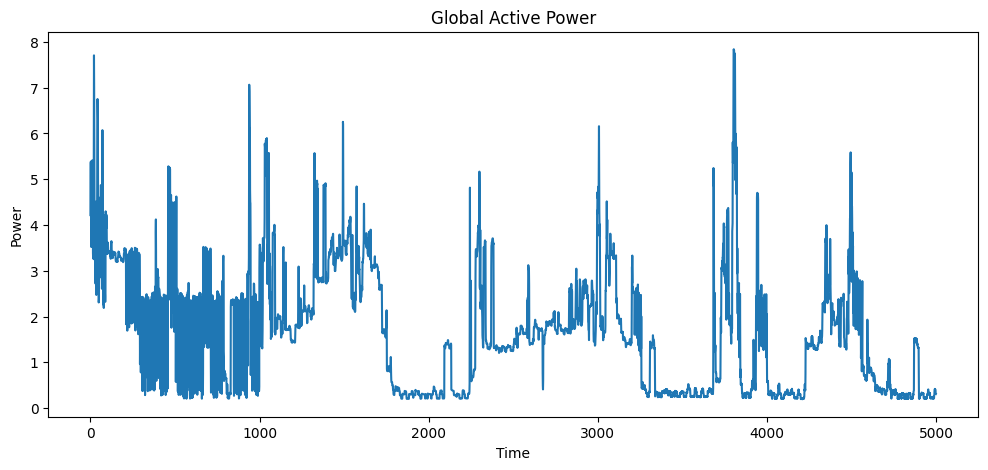

In [10]:
# plot orignal data
plt.figure(figsize=(12,5))
plt.plot(data)
plt.title("Global Active Power")
plt.xlabel("Time")
plt.ylabel("Power")
plt.show()

In [11]:
# train test split
train_size = int(len(data)*0.8)

train = data[:train_size]
test = data[train_size:]

print("Train Size:", len(train))
print("Test Size:", len(test))

Train Size: 4000
Test Size: 1000


In [12]:
# build ARIMA MODEL
model = ARIMA(train, order=(5,1,0))

model_fit = model.fit()

print(model_fit.summary())

                                SARIMAX Results                                
Dep. Variable:     Global_active_power   No. Observations:                 4000
Model:                  ARIMA(5, 1, 0)   Log Likelihood               -2841.793
Date:                 Tue, 02 Jun 2026   AIC                           5695.587
Time:                         21:59:56   BIC                           5733.350
Sample:                              0   HQIC                          5708.973
                                - 4000                                         
Covariance Type:                   opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1282      0.010    -13.291      0.000      -0.147      -0.109
ar.L2         -0.3460      0.010    -34.789      0.000      -0.366      -0.327
ar.L3         -0.2409      0.011    -21.753 

In [13]:
# Forecast
forecast = model_fit.forecast(steps=len(test))

forecast.head()

,predicted_mean
4000,1.217961
4001,1.578954
4002,1.556337
4003,1.644126
4004,1.563257


In [14]:
# RMSE Calculation
rmse = np.sqrt(mean_squared_error(test, forecast))

print("RMSE =", rmse)

RMSE = 1.091497384748398


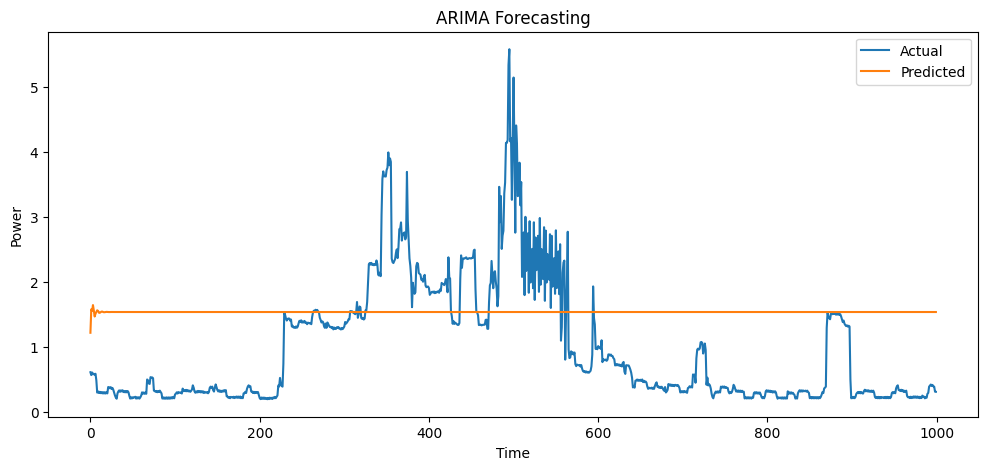

In [15]:
# Actual vs Predicted Graph
plt.figure(figsize=(12,5))

plt.plot(test.values, label='Actual')

plt.plot(forecast.values, label='Predicted')

plt.title("ARIMA Forecasting")

plt.xlabel("Time")

plt.ylabel("Power")

plt.legend()

plt.show()

In [16]:
# Future Prediction
future_forecast = model_fit.forecast(steps=30)

print(future_forecast)

4000    1.217961
4001    1.578954
4002    1.556337
4003    1.644126
4004    1.563257
4005    1.468044
4006    1.510432
4007    1.539442
4008    1.564090
4009    1.554632
4010    1.527201
4011    1.524736
4012    1.533636
4013    1.543065
4014    1.544119
4015    1.537604
4016    1.533970
4017    1.535102
4018    1.538079
4019    1.539483
4020    1.538352
4021    1.536886
4022    1.536617
4023    1.537320
4024    1.537966
4025    1.537926
4026    1.537512
4027    1.537275
4028    1.537371
4029    1.537583
Name: predicted_mean, dtype: float64


Conclusion: The ARIMA model was applied to forecast household electricity consumption.
The model successfully learned patterns from historical data and predicted future values.
The forecasting performance was evaluated using RMSE.
The results show that ARIMA is effective for time-series forecasting problems.